In [1]:
import rioxarray as rxr
from matplotlib.pyplot import imshow
from pyproj.proj import proj_coordoperation_is_instantiable
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import pandas as pd
import rasterio as rio
import matplotlib.pyplot as plt
import shutil


In [20]:
#file paths
QSI_path = "SNEX20_QSI_VH_0.5M_USIDMC_20210315_20210315.tif"
GEDI_path = "Raw/Forest_height_2019_NAM.tif"

QSI = rxr.open_rasterio(QSI_path, masked=True).squeeze()
GEDI = rxr.open_rasterio(GEDI_path, masked=True).squeeze()

print(f'QSI CRS {QSI.rio.crs}')
print(f'GEDI CRS {GEDI.rio.crs}')


QSI CRS PROJCS["unnamed",GEOGCS["Unknown datum based upon the GRS 1980 ellipsoid",DATUM["Not_specified_based_on_GRS_1980_ellipsoid",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6019"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4019"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
GEDI CRS EPSG:4326


In [21]:
QSI = QSI.rio.write_crs("EPSG:26911", inplace=False)


In [22]:
QSI_proj = QSI.rio.reproject(GEDI.rio.crs)
print(QSI_proj.rio.crs)
print(GEDI.rio.crs)


EPSG:4326
EPSG:4326


In [23]:
minx, miny, maxx, maxy = QSI_proj.rio.bounds()
print(minx, miny, maxx, maxy)

-115.73613931299539 43.89832335533891 -115.62192071414964 43.99413236151981


In [24]:
GEDI_crop = GEDI.rio.clip_box(
    minx=minx,
    miny=miny,
    maxx=maxx,
    maxy=maxy
)

In [25]:
print(GEDI_crop.rio.bounds())
print(QSI_proj.rio.bounds())

(-115.73624999999998, 43.898250000000004, -115.62174999999999, 43.99425)
(-115.73613931299539, 43.89832335533891, -115.62192071414964, 43.99413236151981)


In [26]:
print(GEDI.rio.resolution())
print(GEDI_crop.rio.resolution())
print(QSI_proj.rio.resolution())

(0.00025, -0.00025)
(0.00024999999999999654, -0.0002500000000000064)
(5.274954918290064e-06, -5.274954918290064e-06)


In [55]:
QSI_resample = QSI_proj.rio.reproject(QSI_proj.rio.crs,resolution = GEDI_crop.rio.resolution())
print(GEDI_crop.rio.resolution())
print(QSI_resample.rio.resolution())

(0.00024999999999999654, -0.0002500000000000064)
(0.00024999999999999654, -0.0002500000000000064)


In [11]:
GEDI_resample = GEDI_crop.rio.reproject_match(QSI_resample, resampling=Resampling.bilinear)

C:\Users\RDCRLSMC\AppData\Local\miniconda3\envs\iceroad\lib\site-packages\matplotlib\image.py:513: RuntimeWarning: overflow encountered in multiply
  A_resampled *= ((a_max - a_min) / frac)


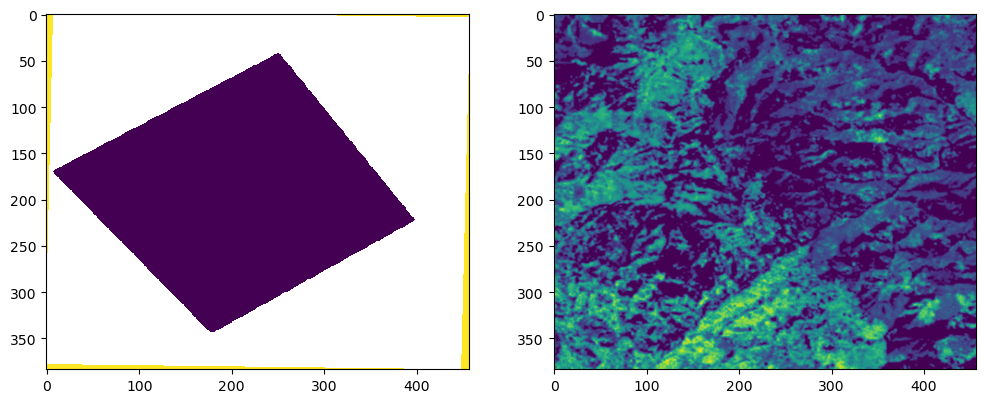

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
axes[0].imshow(QSI_resample)
axes[1].imshow(GEDI_resample)


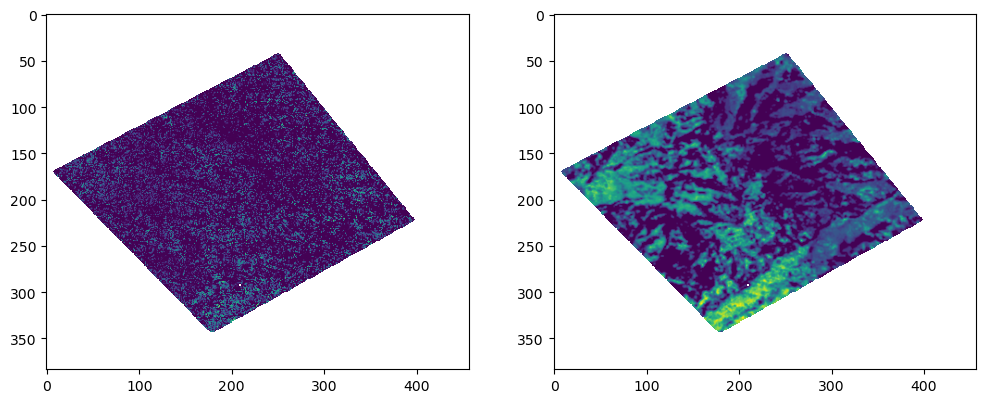

In [45]:
##Mask GEDI by QSI no data values
GEDI_mask = GEDI_resample.where((~np.isnan(QSI_resample)) & (QSI_resample <= 50))
QSI_mask = QSI_resample.where((~np.isnan(QSI_resample)) & (QSI_resample <= 50))

fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
axes[0].imshow(QSI_mask)
axes[1].imshow(GEDI_mask)

In [42]:
# Suppose GEDI_mask is already masked
print("Max:", GEDI_mask.max().item())
print("Min:", GEDI_mask.min().item())

print("Max:", QSI_mask.max().item())
print("Min:", QSI_mask.min().item())

Max: 26.154897689819336
Min: 0.0
Max: 45.0111083984375
Min: 0.0


In [47]:
GEDI_float = GEDI_mask.astype("float32")
QSI_float = QSI_mask.astype("float32")

GEDI_float.rio.to_raster("GEDI_resample1.tif")
QSI_float.rio.to_raster("QSI_resample1.tif")

In [15]:
print(QSI_resample.rio.crs)
print(GEDI_resample.rio.crs)

print(QSI_resample.rio.bounds())
print(GEDI_resample.rio.bounds())

print(QSI_resample.rio.resolution())
print(GEDI_resample.rio.resolution())

EPSG:4326
EPSG:4326
(-115.73613931299539, 43.898132361519814, -115.62188931299539, 43.99413236151981)
(-115.73613931299539, 43.898132361519814, -115.62188931299539, 43.99413236151981)
(0.00024999999999999654, -0.0002500000000000064)
(0.0002500000000000095, -0.0002500000000000064)


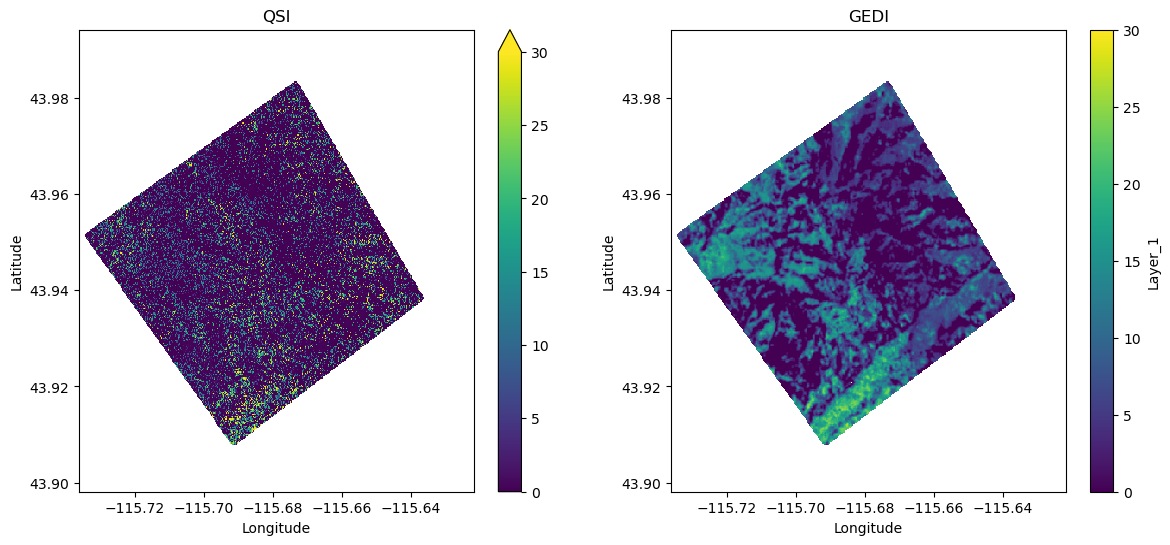

In [48]:
# Load final rasters
GEDI_final = rxr.open_rasterio("GEDI_resample1.tif").squeeze()
QSI_final  = rxr.open_rasterio("QSI_resample1.tif").squeeze()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot QSI
QSI_final.plot(ax=axes[0], cmap='viridis', vmin=0, vmax=30)
axes[0].set_title('QSI')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Plot GEDI
GEDI_final.plot(ax=axes[1], cmap='viridis', vmin=0, vmax=30)
axes[1].set_title('GEDI')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.show()

C:\Users\RDCRLSMC\AppData\Local\miniconda3\envs\iceroad\lib\site-packages\matplotlib\axes\_axes.py:6973: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
C:\Users\RDCRLSMC\AppData\Local\miniconda3\envs\iceroad\lib\site-packages\matplotlib\axes\_axes.py:6974: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([ 0.        ,  2.61548972,  5.23097944,  7.8464694 , 10.46195889,
        13.07744884, 15.6929388 , 18.30842781, 20.92391777, 23.53940773,
        26.15489769]),
 <a list of 457 BarContainer objects>)

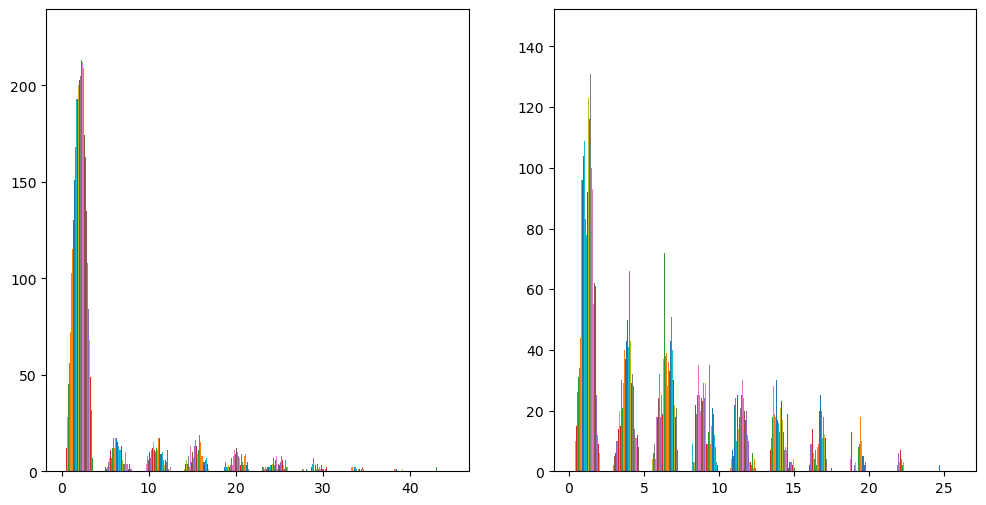

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
axes[0].hist(QSI_final)
axes[1].hist(GEDI_final)